# 01 Data Understanding

Objective: load the raw Athens Airbnb data and inspect structure, missing values, data types and early quality issues.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path("../data/raw")
listings_path = DATA_RAW / "listings.csv.gz"

listings = pd.read_csv(listings_path)
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27262,https://www.airbnb.com/rooms/27262,20250926033717,2025-09-27,previous scrape,"AQA-No7, Great mattress, high speed internet",THE MATTRESS - KING KOIL - Camden Luxury 160x2...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,37177,...,4.97,4.75,4.71,00002433111,t,1,1,0,0,0.18
1,33945,https://www.airbnb.com/rooms/33945,20250926033717,2025-09-26,city scrape,Spacious Cosy aprtm very close to Metro!,Apartment located near metro station. Safe nei...,Neighbourhood is alive all day and safe all da...,https://a0.muscache.com/pictures/1a7a1026-f5f1...,146553,...,4.91,4.64,4.81,00000874421,f,1,1,0,0,0.49
2,49489,https://www.airbnb.com/rooms/49489,20250926033717,2025-09-26,city scrape,Ermou 44 - 3bdr apt in the heart of Athens,"Fully furnished, 98 sq.mt., apartment on 44 Er...",The apartment is located at the commercial cen...,https://a0.muscache.com/pictures/9640239/4bfd2...,225612,...,4.87,4.89,4.69,00000876484,t,3,3,0,0,0.83
3,60394,https://www.airbnb.com/rooms/60394,20250926033717,2025-09-26,city scrape,Cosy apartment! Great central Athens location!,Fully furnished cozy apartment in the best nei...,Very centrally located with a feeling of a qui...,https://a0.muscache.com/pictures/477282/db550f...,290864,...,4.97,4.92,4.92,00000508830,f,1,1,0,0,0.29
4,134340,https://www.airbnb.com/rooms/134340,20250926033717,2025-09-27,previous scrape,Neo Pagrati Athens Apartment,Little gem with the best of all worlds! Locate...,Our street is a small one with very little tra...,https://a0.muscache.com/pictures/1232312/4edeb...,659406,...,4.93,4.56,4.83,00002821300,f,1,1,0,0,0.36


In [53]:
listings.shape

(15584, 79)

In [54]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15584 entries, 0 to 15583
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            15584 non-null  int64  
 1   listing_url                                   15584 non-null  object 
 2   scrape_id                                     15584 non-null  int64  
 3   last_scraped                                  15584 non-null  object 
 4   source                                        15584 non-null  object 
 5   name                                          15584 non-null  object 
 6   description                                   15247 non-null  object 
 7   neighborhood_overview                         7509 non-null   object 
 8   picture_url                                   15584 non-null  object 
 9   host_id                                       15584 non-null 

In [55]:
missing = listings.isna().mean().sort_values(ascending=False).to_frame("missing_rate")
missing.head(30)

,missing_rate
neighbourhood_group_cleansed,1.000000
calendar_updated,1.000000
host_neighbourhood,0.631160
neighbourhood,0.518160
neighborhood_overview,0.518160
host_about,0.493776
host_location,0.332264
review_scores_accuracy,0.150347
first_review,0.150347
last_review,0.150347


## Initial Data Quality Assessment

The raw Athens Airbnb listings dataset contains 15,584 rows and 79 columns. The structure is appropriate for an end-to-end BI and machine learning project because it includes pricing information, geographical variables, property characteristics, host information, review scores, availability metrics and text-based fields.

Several data quality issues are immediately visible:

- `neighbourhood_group_cleansed` and `calendar_updated` are completely missing and should be removed.
- Several descriptive text fields, such as `host_about`, `neighborhood_overview` and `host_neighbourhood`, have high missingness and are not reliable for core modeling.
- The `price` variable has missing values and is stored as an object, meaning it must be cleaned and converted to numeric format.
- Review-related variables have approximately 15% missing values, probably because some listings have no reviews.
- Key property variables such as `bathrooms`, `beds` and `bedrooms` contain some missing values and require imputation or careful filtering.
- Date variables such as `host_since`, `first_review`, `last_review` and `last_scraped` should be converted from object type to datetime format.
- Boolean variables such as `host_is_superhost` and `instant_bookable` should be converted from text values into binary variables.

Overall, the dataset is sufficiently messy to demonstrate data cleaning, feature engineering, exploratory data analysis and predictive modeling.

In [56]:
listings.describe(include="all").T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,15584.0,NaN,NaN,NaN,770125267522933504.0,558434699399727232.0,27262.0,47457772.75,941930747477627520.0,1253466983175896064.0,1517621939131940096.0
listing_url,15584,15584,https://www.airbnb.com/rooms/1511831726128978859,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,15584.0,NaN,NaN,NaN,20250926033717.003906,0.003906,20250926033717.0,20250926033717.0,20250926033717.0,20250926033717.0,20250926033717.0
last_scraped,15584,2,2025-09-26,12747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,15584,2,city scrape,14530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,15584,15367,Wukela Apartment,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,15247,12945,Enjoy a stylish experience at this centrally-l...,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,7509,5614,Most of the central downtown Athens neighborho...,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
picture_url,15584,15452,https://a0.muscache.com/pictures/miso/Hosting-...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,15584.0,NaN,NaN,NaN,285113083.23492,219912729.645246,37177.0,79793951.25,229526838.0,488213362.0,719611943.0


In [57]:
# Check duplicate listing IDs
duplicate_ids = listings["id"].duplicated().sum()
duplicate_rows = listings.duplicated().sum()

duplicate_ids, duplicate_rows

(np.int64(0), np.int64(0))

## Duplicate Check

The duplicate check showed that the dataset does not contain duplicate listing IDs or fully duplicated rows. This confirms that each row represents a unique Airbnb listing, so no duplicate-removal step is required at this stage.

In [58]:
key_columns = [
    "id",
    "name",
    "host_id",
    "host_since",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "amenities",
    "price",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "instant_bookable",
    "estimated_revenue_l365d"
]

listings[key_columns].head()

,id,name,host_id,host_since,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,...,amenities,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,instant_bookable,estimated_revenue_l365d
0,27262,"AQA-No7, Great mattress, high speed internet",37177,2009-09-08,f,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire rental unit,Entire home/apt,...,"[""Hangers"", ""Other electric stove"", ""Dedicated...",NaN,1,1125,0,29,4.86,0.18,t,NaN
1,33945,Spacious Cosy aprtm very close to Metro!,146553,2010-06-17,f,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,23.72775,Entire condo,Entire home/apt,...,"[""Oven"", ""Refrigerator"", ""Bed linens"", ""Hair d...",$45.00,4,1125,269,89,4.76,0.49,f,5760.0
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,2010-09-06,f,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,23.73064,Entire rental unit,Entire home/apt,...,"[""Hangers"", ""Dedicated workspace"", ""Kitchen"", ...",$160.00,2,365,72,142,4.68,0.83,t,1920.0
3,60394,Cosy apartment! Great central Athens location!,290864,2010-11-18,t,ΣΤΑΔΙΟ,37.96738,23.74038,Entire condo,Entire home/apt,...,"[""Hangers"", ""Dedicated workspace"", ""Kitchen"", ...",$50.00,6,210,54,37,4.97,0.29,f,3000.0
4,134340,Neo Pagrati Athens Apartment,659406,2011-06-03,t,ΠΑΓΚΡΑΤΙ,37.96405,23.74968,Entire condo,Entire home/apt,...,"[""Hangers"", ""Dedicated workspace"", ""Kitchen"", ...",NaN,3,90,0,61,4.68,0.36,f,NaN


In [73]:
listings["price"].head(20)

0         NaN
1      $45.00
2     $160.00
3      $50.00
4         NaN
5      $70.00
6      $57.00
7         NaN
8     $400.00
9      $54.00
10     $85.00
11     $83.00
12    $213.00
13     $84.00
14    $150.00
15     $41.00
16    $120.00
17     $74.00
18    $126.00
19     $77.00
Name: price, dtype: object

In [71]:
listings["price"].isna().sum()

np.int64(1060)

In [72]:
listings["price"].isna().mean().round(3)

np.float64(0.068)

## Target Variable Assessment

The `price` variable will be used as the main target variable for the regression model. At this stage, it is stored as an object rather than as a numeric variable, which means that it must be cleaned before modeling. The price values need to be converted from text format into numeric values by removing currency symbols and punctuation.

The variable also contains missing values. Since price is the target variable, rows with missing prices should not be used for supervised price prediction.

In [74]:
price_preview = (
    listings["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

price_preview.describe()

count    14524.000000
mean       122.899821
std        452.296317
min          9.000000
25%         54.000000
50%         78.000000
75%        119.000000
max      38000.000000
Name: price, dtype: float64

In [75]:
price_preview.sort_values(ascending=False).head(20)

9466     38000.0
12211    13680.0
48       10000.0
11221     9429.0
7310      9143.0
7947      9000.0
7949      9000.0
8416      9000.0
7948      9000.0
11149     9000.0
7946      9000.0
14561     8000.0
13784     8000.0
13739     8000.0
11722     8000.0
13738     8000.0
12747     5270.0
12002     5136.0
10225     4888.0
5419      4600.0
Name: price, dtype: float64

In [76]:
price_preview.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01     23.00
0.05     36.00
0.25     54.00
0.50     78.00
0.75    119.00
0.95    296.00
0.99    601.54
Name: price, dtype: float64

## Price Outlier Assessment

The cleaned price preview reveals a strongly right-skewed distribution. The median listing price is much lower than the extreme maximum values. The 99th percentile is approximately €601.54, while the highest observed prices exceed €9,000 and even reach €38,000.

These values are extreme compared with the rest of the market and may represent luxury properties, data entry issues, unusual long-stay pricing, or non-standard listings. If used directly in a regression model, these outliers could distort model training and inflate prediction errors.

For this reason, the cleaning notebook will create a model-ready dataset by excluding missing prices and handling extreme prices. For the BI dashboard, the original cleaned prices can still be retained, but for machine learning, a filtered or log-transformed version of price is more appropriate.

In [82]:
q1 = price_preview.quantile(0.25)
q3 = price_preview.quantile(0.75)
iqr = q3 - q1

iqr_upper_bound = q3 + 1.5 * iqr
p99_upper_bound = price_preview.quantile(0.99)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"IQR upper bound: {iqr_upper_bound:.2f}")
print(f"99th percentile upper bound: {p99_upper_bound:.2f}")

Q1: 54.00
Q3: 119.00
IQR: 65.00
IQR upper bound: 216.50
99th percentile upper bound: 601.54


In [77]:
listings["room_type"].value_counts(dropna=False)

room_type
Entire home/apt    14414
Private room        1068
Hotel room            62
Shared room           40
Name: count, dtype: int64

In [78]:
listings["room_type"].value_counts(normalize=True, dropna=False).round(3)

room_type
Entire home/apt    0.925
Private room       0.069
Hotel room         0.004
Shared room        0.003
Name: proportion, dtype: float64

In [79]:
listings["neighbourhood_cleansed"].value_counts().head(15)

neighbourhood_cleansed
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ              3253
ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ                 1406
ΝΕΟΣ ΚΟΣΜΟΣ                         1174
ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ            1110
ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ    1003
ΠΑΓΚΡΑΤΙ                             630
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ                      590
ΚΟΛΩΝΑΚΙ                             526
ΑΚΡΟΠΟΛΗ                             482
ΑΜΠΕΛΟΚΗΠΟΙ                          477
ΘΗΣΕΙΟ                               468
ΠΕΤΡΑΛΩΝΑ                            458
ΚΕΡΑΜΕΙΚΟΣ                           432
ΚΥΨΕΛΗ                               304
ΣΤΑΔΙΟ                               286
Name: count, dtype: int64

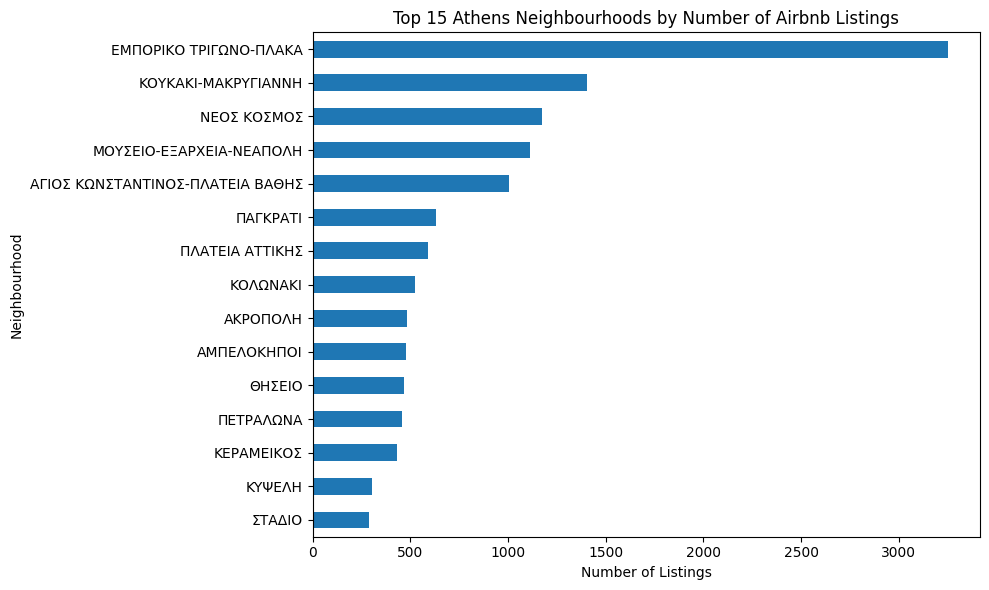

In [80]:
top_15_neighbourhoods = listings["neighbourhood_cleansed"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_15_neighbourhoods.sort_values().plot(kind="barh")
plt.title("Top 15 Athens Neighbourhoods by Number of Airbnb Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()

In [81]:
neighbourhood_share_table = (
    listings["neighbourhood_cleansed"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .head(15)
    .reset_index()
)

neighbourhood_share_table.columns = ["neighbourhood", "share_of_listings"]
neighbourhood_share_table["share_of_listings"] = neighbourhood_share_table["share_of_listings"].astype(str) + "%"

neighbourhood_share_table

,neighbourhood,share_of_listings
0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,20.87%
1,ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,9.02%
2,ΝΕΟΣ ΚΟΣΜΟΣ,7.53%
3,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,7.12%
4,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,6.44%
5,ΠΑΓΚΡΑΤΙ,4.04%
6,ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,3.79%
7,ΚΟΛΩΝΑΚΙ,3.38%
8,ΑΚΡΟΠΟΛΗ,3.09%
9,ΑΜΠΕΛΟΚΗΠΟΙ,3.06%


## Neighbourhood Concentration

The distribution of listings shows a strong geographical concentration in central Athens. The largest number of listings is located in `ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ`, with 3,253 listings, followed by `ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ`, `ΝΕΟΣ ΚΟΣΜΟΣ`, `ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ` and `ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ`.

This pattern suggests that short-term rental activity in Athens is strongly linked to centrality, tourism demand, access to historical sites and proximity to major urban attractions. For the machine learning stage, `neighbourhood_cleansed` is expected to be an important predictor of price and high-price listing potential.

In [66]:
# calculate counts and percentages together
room_type_table = (
    listings["room_type"]
    .value_counts()
    .reset_index()
)

room_type_table.columns = ["room_type", "number_of_listings"]

room_type_table["share_of_listings"] = (
    room_type_table["number_of_listings"] / len(listings) * 100
).round(2).astype(str) + "%"

room_type_table

,room_type,number_of_listings,share_of_listings
0,Entire home/apt,14414,92.49%
1,Private room,1068,6.85%
2,Hotel room,62,0.4%
3,Shared room,40,0.26%


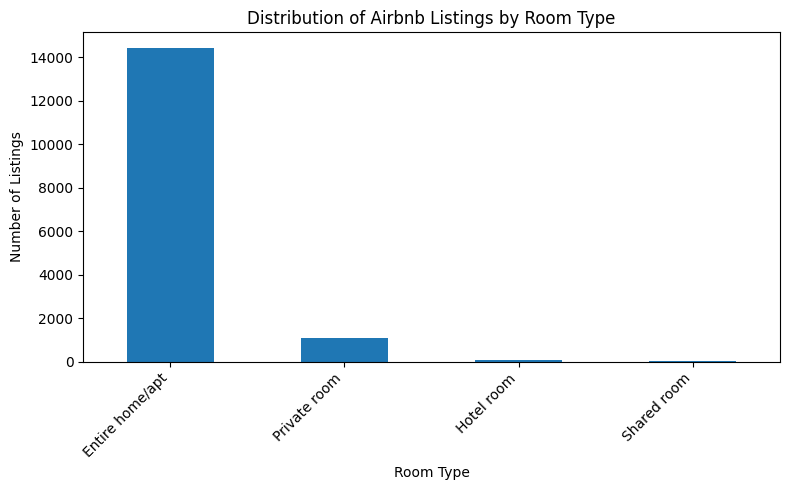

In [67]:
room_type_counts = listings["room_type"].value_counts()

plt.figure(figsize=(8, 5))
room_type_counts.plot(kind="bar")
plt.title("Distribution of Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Room Type Distribution

The room type distribution shows that the Athens Airbnb market is overwhelmingly dominated by entire homes or apartments. Out of 15,584 listings, 14,414 are classified as `Entire home/apt`, representing 92.49% of the dataset.

Private rooms account for only 6.85% of listings, while hotel rooms and shared rooms represent less than 1% combined. This indicates that short-term rental activity in Athens is mainly based on full-property rentals rather than traditional room-sharing.

From a machine learning perspective, `room_type` remains useful as a predictor, but the strong imbalance means that most price variation will likely be explained by other variables such as neighbourhood, property type, accommodates, bedrooms, amenities, review scores and availability.

## Initial Questions

- Which columns are useful for pricing?
- Which columns have too many missing values?
- Which variables require cleaning?
- Which variables should be used for BI only and which for ML?